### Most of the code is from the MEAP paper. 

https://github.com/DhruboSaha/MEAP-RVE-Microstructure-Generator

https://www.sciencedirect.com/science/article/pii/S1359835X25004063?via%3Dihub#da005


# Mesh Grid Initializer

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def initialize_rve_grid(grid_size, initial_value):
    """
    Initializes a 2D array to represent the RVE grid.
    
    Parameters:
        grid_size (tuple): Size of the grid as (rows, columns).
        initial_value (float): Initial value for each grid point.
        
    Returns:
        np.ndarray: Initialized 2D grid.
    """
    # Create a 2D array initialized with the specified large value
    grid = np.full(grid_size, initial_value, dtype=float)
    return grid

# Read Spline Coordinates

In [2]:
import pandas as pd
import random

def read_spline_coordinates(file_path, sheet_number=None):
    """
    Reads spline coordinates (x, y) from a specified or random sheet in an Excel file.
    
    Parameters:
        file_path (str): Path to the Excel file.
        sheet_number (int, optional): The sheet number to read coordinates from.
                                      If None, a random sheet will be chosen.
    
    Returns:
        pd.DataFrame: DataFrame containing spline coordinates with columns ['x', 'y'].
        str: The name of the sheet read.
    """
    # Load the Excel file
    excel_data = pd.ExcelFile(file_path)
    
    # If no sheet number is specified, select a random sheet
    if sheet_number is None:
        sheet_number = random.randint(0, len(excel_data.sheet_names) - 1)
    
    # Read the data from the specified sheet
    sheet_name = excel_data.sheet_names[sheet_number]
    data = pd.read_excel(excel_data, sheet_name=sheet_name, header=None, usecols=[0, 1], names=['x', 'y'])
    
    return data, sheet_name

# Maximum Radius 

In [3]:
import numpy as np

def compute_max_distance_from_centroid(spline_data):
    """
    Computes the maximum distance from the centroid to any point in the spline.
    Handles cases where the first and last coordinates are the same.
    
    Parameters:
        spline_data (pd.DataFrame): DataFrame containing spline coordinates ['x', 'y'].
    
    Returns:
        float: The maximum distance from the centroid to any spline point.
    """
    # Remove the last point if it's identical to the first (to avoid double-counting)
    if (spline_data.iloc[0]['x'] == spline_data.iloc[-1]['x'] and
        spline_data.iloc[0]['y'] == spline_data.iloc[-1]['y']):
        spline_data = spline_data.iloc[:-1]

    # Compute the centroid
    centroid_x = spline_data['x'].mean()
    centroid_y = spline_data['y'].mean()

    # Compute distances from the centroid to all points
    distances = np.sqrt((spline_data['x'] - centroid_x)**2 + (spline_data['y'] - centroid_y)**2)
    
    # Find and return the maximum distance
    return distances.max()

# Scale Spline Coordinates

In [4]:
import numpy as np
import random

def scale_spline(spline_data, scaling_factor=None, scaling_bounds=(0.5, 2.0)):
    """
    Scales a closed spline by a specified or random scaling factor, ensuring 
    the first and last point (identical) are not double-counted in centroid calculation.
    
    Parameters:
        spline_data (pd.DataFrame): DataFrame containing spline coordinates ['x', 'y'].
        scaling_factor (float, optional): The scaling factor to apply. If None, a random scaling factor
                                          between scaling_bounds will be generated.
        scaling_bounds (tuple): Bounds for the random scaling factor as (min, max).
    
    Returns:
        pd.DataFrame: Scaled spline coordinates stored in a new DataFrame ['x', 'y'].
    """
    # Exclude the last point if it's identical to the first (for closed spline)
    if (spline_data.iloc[0]['x'] == spline_data.iloc[-1]['x'] and 
        spline_data.iloc[0]['y'] == spline_data.iloc[-1]['y']):
        valid_data = spline_data.iloc[:-1]
    else:
        valid_data = spline_data
    
    # Compute the centroid
    centroid_x = valid_data['x'].mean()
    centroid_y = valid_data['y'].mean()
    
    # If no scaling factor is provided, generate a random one
    if scaling_factor is None:
        scaling_factor = random.uniform(scaling_bounds[0], scaling_bounds[1])
    
    print(f"Scaling factor: {scaling_factor}")
    
    # Compute the scaled coordinates
    scaled_spline_data = spline_data.copy()
    scaled_spline_data['x'] = centroid_x + (spline_data['x'] - centroid_x) * scaling_factor
    scaled_spline_data['y'] = centroid_y + (spline_data['y'] - centroid_y) * scaling_factor
    
    return scaled_spline_data

# Rotate Spline Coordinates

In [5]:
import numpy as np

def rotate_spline(scaled_spline_data, rotation_angle=None):
    """
    Rotates a spline around its centroid by a specified or random angle.
    
    Parameters:
        scaled_spline_data (pd.DataFrame): DataFrame containing spline coordinates ['x', 'y'].
        rotation_angle (float, optional): The rotation angle in degrees. If None, a random angle 
                                          between 0 and 360 degrees will be selected.
    
    Returns:
        pd.DataFrame: Rotated spline coordinates stored in a new DataFrame ['x', 'y'].
    """
    # Compute the centroid
    centroid_x = scaled_spline_data['x'].mean()
    centroid_y = scaled_spline_data['y'].mean()
    
    # If no rotation angle is provided, generate a random one
    if rotation_angle is None:
        rotation_angle = np.random.uniform(0, 360)
    
    print(f"Rotation angle: {rotation_angle} degrees")
    
    # Convert angle to radians for the rotation matrix
    angle_rad = np.radians(rotation_angle)
    
    # Create the rotation matrix
    rotation_matrix = np.array([
        [np.cos(angle_rad), -np.sin(angle_rad)],
        [np.sin(angle_rad), np.cos(angle_rad)]
    ])
    
    # Shift the points to origin (centroid at (0, 0))
    shifted_points = scaled_spline_data[['x', 'y']].to_numpy() - np.array([centroid_x, centroid_y])
    
    # Apply rotation
    rotated_points = shifted_points.dot(rotation_matrix.T)
    
    # Shift back to the original centroid
    rotated_points += np.array([centroid_x, centroid_y])
    
    # Create a new DataFrame for the rotated spline
    rotated_spline_data = scaled_spline_data.copy()
    rotated_spline_data['x'], rotated_spline_data['y'] = rotated_points[:, 0], rotated_points[:, 1]
    
    return rotated_spline_data

# Displace Spline Coordinates

In [6]:
import numpy as np

def displace_spline_uniformly(spline_data, grid_bounds, displacement=None):
    """
    Displaces the entire spline uniformly by either a specified or random displacement.
    
    Parameters:
        spline_data (pd.DataFrame): DataFrame containing spline coordinates ['x', 'y'].
        grid_bounds (tuple): Bounds of the grid as (grid_rows, grid_columns).
        displacement (tuple, optional): Manually specified displacement as (dx, dy). 
                                        If None, a random displacement is generated.
    
    Returns:
        pd.DataFrame: Displaced spline coordinates stored in a new DataFrame ['x', 'y'].
    """
    grid_rows, grid_columns = grid_bounds
    
    if displacement is None:
        # Generate a single random displacement for x and y
        dx = np.random.uniform(0, grid_columns)
        dy = np.random.uniform(0, grid_rows)
        print(f"Random Displacement (dx, dy): ({dx:.2f}, {dy:.2f})")
    else:
        # Use the manually specified displacement
        dx, dy = displacement
        print(f"Manual Displacement (dx, dy): ({dx:.2f}, {dy:.2f})")
    
    # Apply the uniform displacement to all points
    displaced_spline_data = spline_data.copy()
    displaced_spline_data['x'] += dx
    displaced_spline_data['y'] += dy
    
    return displaced_spline_data

# Periodic Boundary Application

In [7]:
def apply_periodic_boundary_disjoint(displaced_spline_data, grid_bounds, density=100):
    """
    Ensures periodic boundaries by checking and wrapping splines exceeding RVE edges.
    Returns a list of disjoint splines for periodic copies.
    
    Parameters:
        displaced_spline_data (pd.DataFrame): Spline points with columns ['x', 'y'].
        grid_bounds (tuple): Bounds of the grid as (grid_rows, grid_columns).
        density (int): Number of points to interpolate for densification.
    
    Returns:
        list of pd.DataFrame: List of DataFrames for the original and periodic splines.
    """
    grid_rows, grid_cols = grid_bounds
    
    # Extract x and y coordinates from the spline
    x = displaced_spline_data['x'].values
    y = displaced_spline_data['y'].values
    
    # Densify the spline using interpolation
    tck, u = splprep([x, y], s=0)
    u_fine = np.linspace(0, 1, density)
    x_densified, y_densified = splev(u_fine, tck)
    
    # Check which edges are exceeded
    exceeds_left = np.any(x_densified < 0)
    exceeds_right = np.any(x_densified >= grid_cols)
    exceeds_top = np.any(y_densified < 0)
    exceeds_bottom = np.any(y_densified >= grid_rows)
    
    # Initialize a list to hold all splines (original + wrapped)
    splines = []
    
    # Add the original spline
    splines.append(displaced_spline_data)
    
    # Create shifted splines based on boundary exceedance
    if exceeds_left:
        splines.append(displaced_spline_data.copy().assign(x=displaced_spline_data['x'] + grid_cols))
    if exceeds_right:
        splines.append(displaced_spline_data.copy().assign(x=displaced_spline_data['x'] - grid_cols))
    if exceeds_top:
        splines.append(displaced_spline_data.copy().assign(y=displaced_spline_data['y'] + grid_rows))
    if exceeds_bottom:
        splines.append(displaced_spline_data.copy().assign(y=displaced_spline_data['y'] - grid_rows))
    
    # Handle diagonal cases
    if exceeds_left and exceeds_top:
        splines.append(displaced_spline_data.copy().assign(x=displaced_spline_data['x'] + grid_cols,
                                                           y=displaced_spline_data['y'] + grid_rows))
    if exceeds_left and exceeds_bottom:
        splines.append(displaced_spline_data.copy().assign(x=displaced_spline_data['x'] + grid_cols,
                                                           y=displaced_spline_data['y'] - grid_rows))
    if exceeds_right and exceeds_top:
        splines.append(displaced_spline_data.copy().assign(x=displaced_spline_data['x'] - grid_cols,
                                                           y=displaced_spline_data['y'] + grid_rows))
    if exceeds_right and exceeds_bottom:
        splines.append(displaced_spline_data.copy().assign(x=displaced_spline_data['x'] - grid_cols,
                                                           y=displaced_spline_data['y'] - grid_rows))
    
    return splines

# Update Grid

In [8]:
def update_grid_with_periodic_splines_disjoint(rve_grid, periodic_spline_data_list):
    """
    Updates the grid using a list of disjoint splines (original + periodic copies).
    
    Parameters:
        rve_grid (np.ndarray): The 2D mesh grid representing the RVE.
        periodic_spline_data_list (list of pd.DataFrame): List of spline dataframes, each with columns ['x', 'y'].
    
    Returns:
        np.ndarray: Updated grid with zeros for points inside any of the splines.
    """
    # Extract grid dimensions
    grid_rows, grid_columns = rve_grid.shape
    
    # Generate mesh grid coordinates
    x_coords, y_coords = np.meshgrid(np.arange(grid_columns), np.arange(grid_rows))
    mesh_points = np.vstack((x_coords.ravel(), y_coords.ravel())).T
    
    # Initialize a mask for points inside any spline
    inside_mask = np.zeros(len(mesh_points), dtype=bool)
    
    # Check each spline separately
    for spline_data in periodic_spline_data_list:
        spline_path = Path(spline_data[['x', 'y']].values)
        inside_mask |= spline_path.contains_points(mesh_points)  # Combine masks using OR
    
    # Update rve_grid: points inside any spline are set to 0
    updated_grid = rve_grid.copy()
    updated_grid.ravel()[inside_mask] = 0  # Set points inside splines to 0
    
    return updated_grid

# Update Grid Distances

In [9]:
import numpy as np
from scipy.ndimage import distance_transform_edt

def update_grid_distances(updated_rve_grid):
    """
    Updates the grid distances by computing the Euclidean distance of each
    non-zero element to the nearest zero in the grid.
    
    Parameters:
        updated_rve_grid (np.ndarray): The 2D mesh grid with zeros indicating spline regions.
    
    Returns:
        np.ndarray: The grid updated with Euclidean distances for non-zero elements.
    """
    # Compute the distance transform
    distance_grid = distance_transform_edt(updated_rve_grid != 0)
    
    # Return the updated grid with distances
    return distance_grid

# The following functions (uniform, random, clustered) are what determine the placement algorithm to use (RSA/RSE etc.). It can be replaced with anything

# Uniform Distribution 

In [10]:
import numpy as np

def find_most_spacious_point(updated_rve_grid):
    """
    Finds a random point among those with the maximum distance value, 
    representing the most spacious locations.
    
    Parameters:
        updated_rve_grid (np.ndarray): The 2D grid with distance values.
    
    Returns:
        tuple: The (x, y) coordinates of a randomly selected most spacious grid point.
    """
    max_val = np.max(updated_rve_grid)
    
    # Get all indices where the value equals the max
    candidate_indices = np.argwhere(updated_rve_grid == max_val)
    
    # Randomly select one of them
    selected_index = candidate_indices[np.random.choice(len(candidate_indices))]
    
    y, x = selected_index
    return x, y


# Random Distribution

In [11]:
import numpy as np
import random

def find_random_spacious_point(rve_grid, threshold):
    """
    Finds a random point in the grid with a value greater than the given threshold. 
    
    Parameters:
        rve_grid (np.ndarray): The 2D grid with distance values.
        threshold (float): The minimum distance value to consider a point as spacious.
    
    Returns:
        tuple or None: The (x, y) coordinates of a random spacious point, or None if no points meet the threshold.
    """
    # Find indices of all points with values greater than the threshold
    spacious_indices = np.argwhere(rve_grid > threshold)
    
    if spacious_indices.size == 0:
        # No points meet the threshold
        return None
    
    # Randomly select one of the spacious points
    random_index = random.choice(spacious_indices)
    y, x = random_index  # Extract the row and column indices
    
    return x, y

# Clustered Distribution

In [12]:
import numpy as np

def find_least_spacious_point(updated_rve_grid, threshold):
    """
    Finds a random point among those with the minimum distance value 
    that is still above the given threshold, representing the least 
    spacious of the acceptable locations.
    
    Parameters:
        updated_rve_grid (np.ndarray): The 2D grid with distance values.
        threshold (float): Minimum acceptable distance value.
    
    Returns:
        tuple or None: The (x, y) coordinates of a randomly selected 
                       least spacious point above threshold,
                       or None if no such point exists.
    """
    # Create a mask of points above the threshold
    mask = updated_rve_grid >= threshold
    
    if not np.any(mask):
        return None  # No candidate points
    
    # Apply the mask to get all values above the threshold
    valid_values = updated_rve_grid[mask]
    
    # Find the minimum value among the valid points
    min_val = valid_values.min()
    
    # Get all (y, x) indices where the value equals the minimum and above threshold
    candidate_indices = np.argwhere((updated_rve_grid == min_val) & mask)
    
    # Randomly select one candidate
    selected_index = candidate_indices[np.random.choice(len(candidate_indices))]
    
    y, x = selected_index
    return x, y


# Intersection Resolution

In [13]:
import numpy as np
import pandas as pd
from matplotlib.path import Path

def check_and_resolve_intersection(periodic_spline_data_list, updated_rve_grid, scale_factor=0.9):
    """
    Checks for intersection with existing splines and resolves it by iterative scaling.
    
    Parameters:
        periodic_spline_data_list (list of pd.DataFrame): Periodic splines for the new spline.
        updated_rve_grid (np.ndarray): The 2D grid with zeros indicating existing splines.
        scale_factor (float): The factor by which to scale down the splines during intersection resolution.
    
    Returns:
        list of pd.DataFrame: The final periodic splines without intersections.
    """
    def is_intersecting(splines, grid):
        """Checks if any grid point enclosed by the splines corresponds to a zero."""
        grid_rows, grid_columns = grid.shape
        x_coords, y_coords = np.meshgrid(np.arange(grid_columns), np.arange(grid_rows))
        mesh_points = np.vstack((x_coords.ravel(), y_coords.ravel())).T
        
        for spline_data in splines:
            spline_path = Path(spline_data[['x', 'y']].values)
            inside_mask = spline_path.contains_points(mesh_points)
            if np.any(grid.ravel()[inside_mask] == 0):
                return True  # Intersection detected
        return False  # No intersection

    def scale_spline_data(spline_data, factor):
        """
        Scales a single spline's data around its centroid by a given factor.
        Handles cases where the first and last points are identical (closed loop).
        """
        # Check if the first and last points are identical
        if (spline_data.iloc[0]['x'] == spline_data.iloc[-1]['x'] and
            spline_data.iloc[0]['y'] == spline_data.iloc[-1]['y']):
            valid_data = spline_data.iloc[:-1]  # Exclude the last point for centroid calculation
        else:
            valid_data = spline_data

        # Compute the centroid
        centroid_x = valid_data['x'].mean()
        centroid_y = valid_data['y'].mean()

        # Scale the coordinates
        scaled_data = spline_data.copy()
        scaled_data['x'] = centroid_x + (spline_data['x'] - centroid_x) * factor
        scaled_data['y'] = centroid_y + (spline_data['y'] - centroid_y) * factor

        return scaled_data

    # Start resolving intersections
    while is_intersecting(periodic_spline_data_list, updated_rve_grid):
        print("Intersection detected. Scaling down splines...")
        # Scale down all splines in the periodic_spline_data_list
        periodic_spline_data_list = [
            scale_spline_data(spline, scale_factor) for spline in periodic_spline_data_list
        ]
    
    print("No intersection detected. Final spline placement resolved.")
    return periodic_spline_data_list

# Area Computation

In [14]:
from scipy.interpolate import splprep, splev
import pandas as pd
import numpy as np

def compute_area_from_final_splines(final_splines, density=100):
    """
    Computes the area of the first spline in final_splines after resolving intersections.
    The spline is densified using scipy.interpolate before calculating the area.
    
    Parameters:
        final_splines (list of pd.DataFrame): List of DataFrames representing periodic splines.
        density (int): Number of points to interpolate for densification.
    
    Returns:
        float: The area of the first spline in final_splines.
    """
    if not final_splines:
        raise ValueError("final_splines is empty. Cannot compute area.")

    # Take the first spline from final_splines
    first_spline = final_splines[0]

    # Densify the spline using scipy.interpolate
    def densify_spline(spline_data, density):
        x = spline_data['x'].values
        y = spline_data['y'].values

        # Create a parameterized spline
        tck, u = splprep([x, y], s=0)  # s=0 ensures interpolation through all points
        u_fine = np.linspace(0, 1, density)
        x_densified, y_densified = splev(u_fine, tck)

        # Return as a DataFrame
        return pd.DataFrame({'x': x_densified, 'y': y_densified})
    
    densified_spline = densify_spline(first_spline, density)

    # Compute the area using the Shoelace formula
    def compute_spline_area(spline_data):
        x = spline_data['x'].values
        y = spline_data['y'].values

        # Ensure the spline is closed
        if x[0] != x[-1] or y[0] != y[-1]:
            x = np.append(x, x[0])
            y = np.append(y, y[0])

        # Apply the Shoelace formula
        area = 0.5 * np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))
        return area

    # Compute and return the area
    return compute_spline_area(densified_spline)

In [15]:
def estimate_area(rve_grid):
    """
    Returns the fraction (in decimal) of elements in rve_grid that are exactly zero.
    
    Parameters:
        rve_grid (np.ndarray): 2D array representing the RVE grid.
    
    Returns:
        float: Fraction of zero elements (e.g., 0.25 for 25%)
    """
    total = rve_grid.size
    zeros = np.count_nonzero(rve_grid == 0)
    return zeros / total


# Visualize Splines

In [16]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

def visualize_rve_shaded_single_color(all_splines, grid_bounds, shape_color="#939598", background_color="#C8C9CB", alpha=1.0):
    """
    Visualizes the RVE with all splines stored in the all_splines list,
    shading the insides of the splines with a single specified color and a custom background color.
    There are no outlines for the shapes.

    Parameters:
        all_splines (list of pd.DataFrame): List of DataFrames representing all splines added so far.
        grid_bounds (tuple): The dimensions of the RVE grid as (grid_rows, grid_columns).
        shape_color (str): Color for shading the insides of the splines.
        background_color (str): Color for the background outside the shapes.
        alpha (float): The transparency level for the shaded areas (0 is fully transparent, 1 is fully opaque).
    """
    grid_rows, grid_columns = grid_bounds

    # Create a new plot with the specified background color
    plt.figure(figsize=(10*(grid_columns/grid_rows), 10))
    plt.gca().set_facecolor(background_color)
    
    # Set up the plot limits based on the grid bounds
    plt.xlim(0, grid_columns)
    plt.ylim(0, grid_rows)
    
    # Invert the Y-axis for proper alignment with grid coordinates
    plt.gca().invert_yaxis()

    patches = []  # Collect all spline polygons for efficient plotting

    # Plot each spline in the RVE
    for spline_data in all_splines:
        x = spline_data['x'].values
        y = spline_data['y'].values

        # Create a polygon for the spline
        polygon = Polygon(list(zip(x, y)), closed=True)
        patches.append(polygon)

    # Add all spline polygons to the plot with the specified shape color
    patch_collection = PatchCollection(patches, facecolor=shape_color, edgecolor="none", alpha=alpha)
    plt.gca().add_collection(patch_collection)

    # Remove ticks
    plt.xticks([])  # Disable xticks
    plt.yticks([])  # Disable yticks

    # Show the plot
    plt.show()

# Phase Fraction from RVE

In [17]:
import numpy as np

def calculate_phase_fraction(rve_grid):
    """
    Calculates the phase fraction of zeros in the RVE grid.
    
    Parameters:
        rve_grid (np.ndarray): The 2D grid representing the RVE.
    
    Returns:
        float: The phase fraction (fraction of zeros in the grid).
    """
    total_points = rve_grid.size  # Total number of grid points
    zero_points = np.sum(rve_grid == 0)  # Number of points with zero value
    
    phase_fraction = zero_points / total_points  # Fraction of zeros
    return phase_fraction

# Shrink splines slightly at the end

In [18]:
import pandas as pd

#At the end, splines may be too close together and cause meshing difficulties in FE Software
#So shrink everything slightly to prevent that.

def scale_down_spline(spline_data, scaling_factor):
    """
    Scales down a single spline by a constant factor from its centroid.
    
    Parameters:
        spline_data (pd.DataFrame): DataFrame containing spline coordinates ['x', 'y'].
        scaling_factor (float): The factor by which to scale the spline (0 < scaling_factor < 1).
    
    Returns:
        pd.DataFrame: The scaled-down spline coordinates ['x', 'y'].
    """
    # Ensure scaling factor is valid
    if scaling_factor <= 0 or scaling_factor >= 1:
        raise ValueError("Scaling factor must be between 0 and 1.")

    # Remove the last point if it's identical to the first (closed spline)
    if (spline_data.iloc[0]['x'] == spline_data.iloc[-1]['x'] and
        spline_data.iloc[0]['y'] == spline_data.iloc[-1]['y']):
        valid_spline_data = spline_data.iloc[:-1]
    else:
        valid_spline_data = spline_data

    # Compute the centroid
    centroid_x = valid_spline_data['x'].mean()
    centroid_y = valid_spline_data['y'].mean()

    # Scale the coordinates
    scaled_spline = spline_data.copy()
    scaled_spline['x'] = centroid_x + (spline_data['x'] - centroid_x) * scaling_factor
    scaled_spline['y'] = centroid_y + (spline_data['y'] - centroid_y) * scaling_factor

    return scaled_spline


def create_scaled_down_all_splines(all_splines, scaling_factor):
    """
    Creates a scaled-down version of all_splines by applying the scaling factor to each spline.
    
    Parameters:
        all_splines (list of pd.DataFrame): List of splines represented as DataFrames.
        scaling_factor (float): The factor by which to scale each spline (0 < scaling_factor < 1).
    
    Returns:
        list of pd.DataFrame: List of scaled-down splines.
    """
    scaled_down_all_splines = []
    for spline_data in all_splines:
        scaled_down_spline = scale_down_spline(spline_data, scaling_factor)
        scaled_down_all_splines.append(scaled_down_spline)
    
    return scaled_down_all_splines

# Export Data to Excel

In [19]:
import pandas as pd

def export_splines_to_excel(all_splines, file_name="splines_export.xlsx"):
    """
    Exports the spline data in all_splines to an Excel file.
    Each spline is written to a separate sheet in the file.

    Parameters:
        all_splines (list of pd.DataFrame): List of DataFrames representing splines.
        file_name (str): The name of the output Excel file.

    Returns:
        None
    """
    # Create an Excel writer object
    with pd.ExcelWriter(file_name, engine="xlsxwriter") as writer:
        for i, spline_data in enumerate(all_splines):
            sheet_name = f"Spline_{i+1}"
            spline_data.to_excel(writer, index=False, sheet_name=sheet_name)
    
    print(f"Spline data exported successfully to {file_name}")

# Main Program Loops will be implemented now as all functions have been defined above

# Uniform Distribution

In [33]:
# Parameters
grid_rows = 500  # Number of rows
grid_cols = 500  # Number of columns
initial_value = 1e9  # A large initial value for the grid points
rve_area = grid_rows*grid_cols
# Initialize the grid
rve_grid = initialize_rve_grid((grid_rows, grid_cols), initial_value)
file_path = 'All Shapes Same Area.xlsx'  # Replace with the correct path

scaling_factor = None # grid_rows/0.7  # Specify a float value for a fixed factor, or leave as None for random
scaling_bounds = (25,100)  # Bounds for random scaling factor

# Example usage
rotation_angle = None  # Specify an angle in degrees or leave as None for a random angle

# Example usage
grid_bounds = (grid_rows, grid_cols)  # Replace with actual grid dimensions (grid_rows, grid_columns)

# Use either a manually specified displacement or let it be randomly generated
manual_displacement = None  # Replace with (dx, dy), e.g., (10, 15), for manual displacement

all_splines = []

accumulated_area = 0

while accumulated_area/rve_area < 0.65:

    sheet_number = None  # Set to a specific integer for a chosen sheet or leave as None for random
    # Read spline coordinates
    spline_data, chosen_sheet_name = read_spline_coordinates(file_path, sheet_number)
    
    scaled_spline_data = scale_spline(spline_data, scaling_factor, scaling_bounds)
    rotated_spline_data = rotate_spline(scaled_spline_data, rotation_angle)
    displaced_spline_data = displace_spline_uniformly(rotated_spline_data, grid_bounds, manual_displacement)
    
    periodic_spline_data_list = apply_periodic_boundary_disjoint(displaced_spline_data, grid_bounds)
    non_intersecting_splines = check_and_resolve_intersection(periodic_spline_data_list, rve_grid)
    
    spline_area = compute_area_from_final_splines(non_intersecting_splines, density=100)
    print(spline_area)
    accumulated_area += spline_area
    print("Phase Fraction: " + str(accumulated_area/rve_area))
    
    rve_grid = update_grid_with_periodic_splines_disjoint(rve_grid, non_intersecting_splines)
    rve_grid = update_grid_distances(rve_grid)
    
    # Append the final splines to the storage
    all_splines.extend(non_intersecting_splines)  # Add each periodic spline to the list
    
    most_spacious_point = find_most_spacious_point(rve_grid)
    manual_displacement = most_spacious_point

Scaling factor: 89.46984355070124
Rotation angle: 307.8068068274022 degrees
Random Displacement (dx, dy): (64.19, 233.93)
No intersection detected. Final spline placement resolved.
2832.8337540769717
Phase Fraction: 0.011331335016307887
Scaling factor: 56.63166024660974
Rotation angle: 83.27120518405475 degrees
Manual Displacement (dx, dy): (499.00, 499.00)
No intersection detected. Final spline placement resolved.
1152.5991701036692
Phase Fraction: 0.015941731696722562
Scaling factor: 98.36075866213106
Rotation angle: 253.7874662048285 degrees
Manual Displacement (dx, dy): (361.00, 247.00)
No intersection detected. Final spline placement resolved.
3398.387520405464
Phase Fraction: 0.02953528177834442
Scaling factor: 85.66246984327921
Rotation angle: 334.4184460948146 degrees
Manual Displacement (dx, dy): (240.00, 11.00)
No intersection detected. Final spline placement resolved.
2627.8134456263506
Phase Fraction: 0.04004653556084982
Scaling factor: 55.31843058489311
Rotation angle: 351

Scaling factor: 87.708466659262
Rotation angle: 130.43935769512123 degrees
Manual Displacement (dx, dy): (191.00, 283.00)
No intersection detected. Final spline placement resolved.
2716.258256156463
Phase Fraction: 0.266835369216423
Scaling factor: 86.4257875872556
Rotation angle: 105.45153682166402 degrees
Manual Displacement (dx, dy): (0.00, 210.00)
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down

Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
1232.8396616298705
Phase Fraction: 0.37882433355161416
Scaling factor: 35.04958397958471
Rotation angle: 310.33811188295834 degrees
Manual Displacement (dx, dy): (362.00, 54.00)
No intersection detected. Final spline placement resolved.
441.4946547038853
Phase Fraction: 0.38059031217042966
Scaling factor: 76.07555818228988
Rotation angle: 260.991107349477 degrees
Manual Displacement (dx, dy): (418.00, 443.00)
Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
1678.7601850498468
Phase Fraction: 0.38730535291062906
Scaling factor: 35.86978994050631
Rotation angle: 340.23076280767947 degrees
Manual Displacement (dx, dy): (273.00, 463.00)
No intersection detected. Final spline placement resolved.
454.30308806244284
Phase Fraction: 0.38912256526287886
Scaling factor: 73.23585554562266
Rotation angle: 294.5331878838557 degrees
Manual

Scaling factor: 25.396886403367144
Rotation angle: 186.28306528292038 degrees
Manual Displacement (dx, dy): (165.00, 337.00)
No intersection detected. Final spline placement resolved.
226.6496663009748
Phase Fraction: 0.4721890172142941
Scaling factor: 38.730301079238785
Rotation angle: 133.71347768927814 degrees
Manual Displacement (dx, dy): (341.00, 200.00)
No intersection detected. Final spline placement resolved.
527.1034724805504
Phase Fraction: 0.4742974311042163
Scaling factor: 74.28003346266601
Rotation angle: 78.94657686547579 degrees
Manual Displacement (dx, dy): (107.00, 489.00)
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
1273.842758516781
Phase Fraction: 0.47939280213828345
Scaling factor: 48.08519508179813
Rotation angle: 184.98936957290994 degrees
Manual Displacement (dx, dy): (450.00, 357.00)
No intersection detected. Final spline placement resolved.
830.964517226

Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
694.0753382197581
Phase Fraction: 0.5265508208633857
Scaling factor: 88.42305934026561
Rotation angle: 28.861260151324068 degrees
Manual Displacement (dx, dy): (36.00, 40.00)
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
520.6800522604899
Phase Fraction: 0.5286335410724277
Scaling factor: 39.042027323143486
Rotation angle: 321.1868972398377 degrees
Manual Displacement (dx, dy): (476.00, 474.00)
No intersection detected. Final spline placement resolved.
536.3722803574055
Phase Fraction: 0.530779030193

...

Scaling factor: 25.29387108756009
Rotation angle: 132.51815037465641 degrees
Manual Displacement (dx, dy): (81.00, 372.00)
No intersection detected. Final spline placement resolved.
226.54698440944776
Phase Fraction: 0.5858856143449054
Scaling factor: 44.411660987657356
Rotation angle: 164.30265014242187 degrees
Manual Displacement (dx, dy): (245.00, 387.00)
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
368.8507679766044
Phase Fraction: 0.5873610174168118
Scaling factor: 27.87239714576569
Rotation angle: 71.10975242862995 degrees
Manual Displacement (dx, dy): (381.00, 353.00)
No intersection detected. Final spline placement resolved.
279.195463815704
Phase Fraction: 0.5884777992720746
Scaling factor: 93.43904347835593
Rotation angle: 348.00958935137083 degrees
Manual Displacement (dx, dy): (404.00, 388.00)
Intersection detected. Scali

Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
236.31447319569997
Phase Fraction: 0.6051488456311405
Scaling factor: 78.28413288200741
Rotation angle: 49.42528400500672 degrees
Manual Displacement (dx, dy): (461.00, 150.00)
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
323.226375233382
Phase Fraction: 0.606441751132

Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
215.32390006352216
Phase Fraction: 0.6180972597367994
Scaling factor: 57.301805915432304
Rotation angle: 201.70891102777887 degrees
Manual Displacement (dx, dy): (15.00, 384.00)
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
214.8348791230237
Phase Fraction: 0.6189565992532915
Scaling factor: 87.95863154385344
Rotation angle: 161.01075376842022 degrees
Manual Dis

Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
223.94260999793187
Phase Fraction: 0.6315489442059595
Scaling factor: 64.85271567896831
Rotation angle: 301.6165002648355 degrees
Manual Displacement (dx, dy): (206.00, 196.00)
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
221.74338039616123
Phase Fraction: 0.6324359177275442
Scaling factor: 57.73196491182435
Rotati

No intersection detected. Final spline placement resolved.
140.10939748981036
Phase Fraction: 0.645309766764424
Scaling factor: 66.18202891306066
Rotation angle: 229.82920307556742 degrees
Manual Displacement (dx, dy): (72.00, 81.00)
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
187.54366390773794
Phase Fraction: 0.6460599414200549
Scaling factor: 44.102074502893544
Rotation angle: 242.69044729715307 degrees
Manual Displacement (dx, dy): (75.00, 337.00)
Intersection detected. Scaling down splines...
Intersection

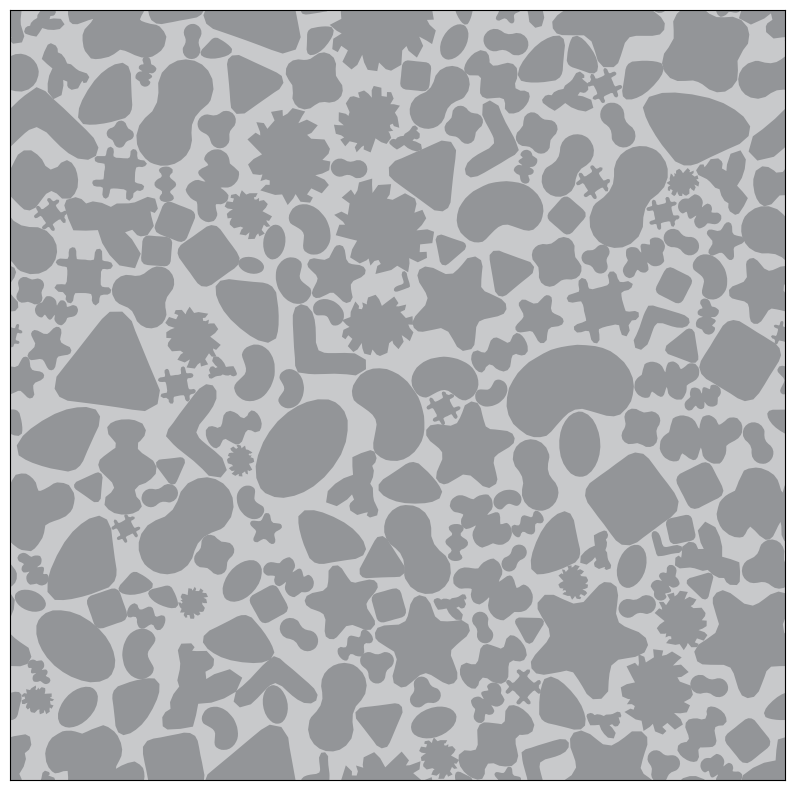

In [34]:
visualize_rve_shaded_single_color(all_splines, grid_bounds=(grid_rows, grid_cols))

# Now let's make some loops to create CNN datasets

# Generate CNN Training Images and Annotation Files

There is an important line about inclusions at the edges of the RVE in this code snippet. Take note of that.

A folder called output will be created and the synthetic data stored there

In [47]:
import os
import cv2

# Auto-generate sheet_name → class_id mapping
excel_data = pd.ExcelFile(file_path)
sheet_name_to_class_id = {name: idx for idx, name in enumerate(excel_data.sheet_names)}

# Output directories
image_dir = "output/images"
label_dir = "output/labels"
os.makedirs(image_dir, exist_ok=True)
os.makedirs(label_dir, exist_ok=True)


for i in range(500):
    # Parameters
    grid_rows = 1000  # Number of rows
    grid_cols = 1000  # Number of columns
    initial_value = 1e9  # A large initial value for the grid points
    rve_area = grid_rows*grid_cols
    # Initialize the grid
    rve_grid = initialize_rve_grid((grid_rows, grid_cols), initial_value)
    file_path = 'All Shapes Same Area.xlsx'  # Replace with the correct path

    scaling_factor = None # grid_rows/0.7  # Specify a float value for a fixed factor, or leave as None for random
    scaling_bounds = (50,200)  # Bounds for random scaling factor

    # Example usage
    rotation_angle = None  # Specify an angle in degrees or leave as None for a random angle

    # Example usage
    grid_bounds = (grid_rows, grid_cols)  # Replace with actual grid dimensions (grid_rows, grid_columns)

    # Use either a manually specified displacement or let it be randomly generated
    manual_displacement = None  # Replace with (dx, dy), e.g., (10, 15), for manual displacement

    all_splines = []

    accumulated_area = 0


    while accumulated_area/rve_area < 0.6:

        sheet_number = None  # Set to a specific integer for a chosen sheet or leave as None for random
        # Read spline coordinates
        spline_data, chosen_sheet_name = read_spline_coordinates(file_path, sheet_number)

        scaled_spline_data = scale_spline(spline_data, scaling_factor, scaling_bounds)
        rotated_spline_data = rotate_spline(scaled_spline_data, rotation_angle)
        displaced_spline_data = displace_spline_uniformly(rotated_spline_data, grid_bounds, manual_displacement)

        periodic_spline_data_list = apply_periodic_boundary_disjoint(displaced_spline_data, grid_bounds)
        non_intersecting_splines = check_and_resolve_intersection(periodic_spline_data_list, rve_grid)

        spline_area = compute_area_from_final_splines(non_intersecting_splines, density=100)
        print(spline_area)
        accumulated_area += spline_area
        print("Phase Fraction: " + str(accumulated_area/rve_area))

        rve_grid = update_grid_with_periodic_splines_disjoint(rve_grid, non_intersecting_splines)
        rve_grid = update_grid_distances(rve_grid)

        # Append the final splines to the storage
        for spline in non_intersecting_splines:
            class_id = sheet_name_to_class_id[chosen_sheet_name]
            all_splines.append((spline, class_id))


        most_spacious_point = find_most_spacious_point(rve_grid)
        manual_displacement = most_spacious_point

        
    # IMPORTANT!!!!!!!
    #IF YOU WANT TO GET RID OF INCLUSIONS CUT AT THE EDGES, THE FOLLOWING LINE IS USED. OTHERWISE THE FOLLOWING LINE IS NOT USED 
    
    all_splines = [(spline_df, class_id) for spline_df, class_id in all_splines if ((spline_df["x"] >= 0) & (spline_df["x"] < grid_cols) & (spline_df["y"] >= 0) & (spline_df["y"] < grid_rows)).all()]
    
        
    canvas = np.full((grid_rows, grid_cols, 3), 255, dtype=np.uint8)

    for spline_df, _ in all_splines:
        pts = spline_df[["x", "y"]].to_numpy().astype(np.int32)
        cv2.fillPoly(canvas, [pts], color=(0, 0, 0))

    image_path = os.path.join(image_dir, f"RVE_{i}.png")
    cv2.imwrite(image_path, canvas)

    label_path = os.path.join(label_dir, f"RVE_{i}.txt")
    with open(label_path, "w") as f:
        for spline_df, class_id in all_splines:
            coords = spline_df[["x", "y"]].to_numpy(dtype=float)
            coords[:, 0] /= grid_cols  # Normalize x
            coords[:, 1] /= grid_rows  # Normalize y
            flat_coords = coords.flatten()
            coord_str = " ".join(f"{v:.6f}" for v in flat_coords)
            f.write(f"{class_id} {coord_str}\n")


Scaling factor: 162.48652340486075
Rotation angle: 220.4776363589825 degrees
Random Displacement (dx, dy): (522.44, 609.53)
No intersection detected. Final spline placement resolved.
9287.262282200158
Phase Fraction: 0.009287262282200158
Scaling factor: 161.1342094522001
Rotation angle: 181.40607805680705 degrees
Manual Displacement (dx, dy): (0.00, 0.00)
No intersection detected. Final spline placement resolved.
9115.62915767026
Phase Fraction: 0.01840289143987042
Scaling factor: 103.86406715391472
Rotation angle: 59.416268405401425 degrees
Manual Displacement (dx, dy): (0.00, 502.00)
No intersection detected. Final spline placement resolved.
3863.1715700710774
Phase Fraction: 0.022266063009941495
Scaling factor: 115.37611297564506
Rotation angle: 249.57370756635402 degrees
Manual Displacement (dx, dy): (494.00, 114.00)
No intersection detected. Final spline placement resolved.
4684.178219072521
Phase Fraction: 0.026950241229014016
Scaling factor: 158.44990530642409
Rotation angle: 25

Scaling factor: 83.6600919239403
Rotation angle: 2.181656194548678 degrees
Manual Displacement (dx, dy): (195.00, 272.00)
No intersection detected. Final spline placement resolved.
2464.95348515315
Phase Fraction: 0.2256798451533603
Scaling factor: 148.73400378710124
Rotation angle: 245.3096314574368 degrees
Manual Displacement (dx, dy): (999.00, 872.00)
No intersection detected. Final spline placement resolved.
7811.03457082808
Phase Fraction: 0.23349087972418836
Scaling factor: 55.438905141686625
Rotation angle: 321.63018285561014 degrees
Manual Displacement (dx, dy): (501.00, 759.00)
No intersection detected. Final spline placement resolved.
1081.5108806565404
Phase Fraction: 0.2345723906048449
Scaling factor: 122.06148034771479
Rotation angle: 322.5936973556563 degrees
Manual Displacement (dx, dy): (593.00, 476.00)
No intersection detected. Final spline placement resolved.
5230.8035394102335
Phase Fraction: 0.23980319414425513
Scaling factor: 107.61349223099936
Rotation angle: 98.7

Scaling factor: 155.36169003848954
Rotation angle: 295.28659856415504 degrees
Manual Displacement (dx, dy): (88.00, 499.00)
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
3708.363863904495
Phase Fraction: 0.376813322252162
Scaling factor: 122.58809118825465
Rotation angle: 190.16762337552103 degrees
Manual Displacement (dx, dy): (622.00, 558.00)
No intersection detected. Final spline placement resolved.
5318.195499006659
Phase Fraction: 0.3821315177511687
Scaling factor: 112.40842268752738
Rotation angle: 110.28875824762494 degrees
Manual Displacement (dx, dy): (464.00, 700.00)
No intersection detected. Final spline placement resolved.
4438.404383379966
Phase Fraction: 0.38656992213454866
Scaling factor: 60.53370088821019
Rotation angle: 358.739954824407 degrees
Manual Displacement (dx, dy

Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
1348.0000133141875
Phase Fraction: 0.4587873360391754
Scaling factor: 94.41795064232315
Rotation angle: 95.17847136937121 degrees
Manual Displacement (dx, dy): (0.00, 154.00)
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection d

Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
2383.9826175989583
Phase Fraction: 0.49483721698108274
Scaling factor: 103.50648900175904
Rotation angle: 293.78262184023663 degrees
Manual Displacement (dx, dy): (739.00, 350.00)
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
2517.204729001969
Phase Fraction: 0.4973544217100847
Scaling factor: 57.811357312983446
Rotation angle: 44.15053650182535 degrees
Manual Displacement (dx, dy): (414.00, 901.00)
No intersection detected. Final spline placement resolved.
1178.8952183760703
Phase Fraction: 0.4985333169284608
Scaling factor: 51.85399690065053
Rotation angle: 331.4007864700522 degrees
Manual 

...

Scaling factor: 172.33030665146777
Rotation angle: 337.25523445088464 degrees
Manual Displacement (dx, dy): (300.00, 381.00)
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
1027.2772962125018
Phase Fraction: 0.5956513140283072
Scaling factor: 187.74899023901014
Rotation angle: 186.78285066917675 degrees
Manual Displacement (dx, dy): (891.00, 432.00)
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Sca

Scaling factor: 194.9883553496689
Rotation angle: 336.01745583581123 degrees
Manual Displacement (dx, dy): (552.00, 183.00)
No intersection detected. Final spline placement resolved.
13463.09890771471
Phase Fraction: 0.11631595916530721
Scaling factor: 131.8223699824788
Rotation angle: 265.94076425335976 degrees
Manual Displacement (dx, dy): (47.00, 195.00)
No intersection detected. Final spline placement resolved.
6114.765888020047
Phase Fraction: 0.12243072505332726
Scaling factor: 131.18739240124467
Rotation angle: 34.04362863095489 degrees
Manual Displacement (dx, dy): (507.00, 480.00)
No intersection detected. Final spline placement resolved.
6142.407012825832
Phase Fraction: 0.1285731320661531
Scaling factor: 50.580041236994475
Rotation angle: 86.64112146554471 degrees
Manual Displacement (dx, dy): (765.00, 668.00)
No intersection detected. Final spline placement resolved.
916.1607982255518
Phase Fraction: 0.12948929286437863
Scaling factor: 174.85292692948957
Rotation angle: 242

Scaling factor: 177.92355048968554
Rotation angle: 181.21730384888667 degrees
Manual Displacement (dx, dy): (389.00, 406.00)
Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
9053.987984055653
Phase Fraction: 0.29985495967847736
Scaling factor: 150.6547798170859
Rotation angle: 125.41094049924105 degrees
Manual Displacement (dx, dy): (384.00, 760.00)
Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
6454.49089484103
Phase Fraction: 0.30630945057331843
Scaling factor: 161.0528766720339
Rotation angle: 159.28056566838856 degrees
Manual Displacement (dx, dy): (120.00, 619.00)
Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
7550.604223086964
Phase Fraction: 0.3138600547964054
Scaling factor: 143.28845101319735
Rotation angle: 290.8836641686426 degrees
Manual Displacement (dx, dy): (735.00, 110.00)
No intersection detected.

Scaling factor: 151.45935466718973
Rotation angle: 313.61287847374564 degrees
Manual Displacement (dx, dy): (933.00, 554.00)
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
2821.4098144359887
Phase Fraction: 0.42602478187563225
Scaling factor: 108.65885127402336
Rotation angle: 226.45157896279935 degrees
Manual Displacement (dx, dy): (170.00, 924.00)
No intersection detected. Final spline placement resolved.
4168.868929212913
Phase Fraction: 0.4301936508048452
Scaling factor: 85.85323978168444
Rotation angle: 83.06117414255743 degrees
Manual Displacement (dx, dy): (574.00, 0.00)
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scal

KeyboardInterrupt: 

### We will get rid of the inclusions at the edges from the annotation files. Because those inclusions often don't have a clear shape. This following snippet is not mandatory and only if you the annotation text files have normalized coordinates outside the 0-1 range. If you got rid of periodic inclusions (those cut at the edges) already in the previous code snippet, then this is not needed. 

In [ ]:
import os

# Set your input and output directories
labels_dir = "output/labels/val"
cleaned_labels_dir = "output/labels/val"

os.makedirs(cleaned_labels_dir, exist_ok=True)

# Check and clean all label files
for filename in os.listdir(labels_dir):
    if not filename.endswith('.txt'):
        continue

    input_path = os.path.join(labels_dir, filename)
    output_path = os.path.join(cleaned_labels_dir, filename)

    with open(input_path, 'r') as infile, open(output_path, 'w') as outfile:
        for line in infile:
            parts = line.strip().split()

            try:
                floats = list(map(float, parts[1:]))  # Skip class_id
                if all(0.0 <= val <= 1.0 for val in floats):
                    outfile.write(line)
                else:
                    # Skip instance with out-of-bounds coordinates
                    continue
            except ValueError:
                # Skip malformed line
                continue


# Single Shape RVEs for inference

We will make some images for inference which have a single shape in each RVE

The synthetic data will be sent to the output folder

In [46]:
import os
import cv2

# Auto-generate sheet_name → class_id mapping
excel_data = pd.ExcelFile(file_path)
sheet_name_to_class_id = {name: idx for idx, name in enumerate(excel_data.sheet_names)}

# Output directories
image_dir = "output/imagesTest"
label_dir = "output/labelsTest"
os.makedirs(image_dir, exist_ok=True)
os.makedirs(label_dir, exist_ok=True)


for i in range(15):
    # Parameters
    grid_rows = 1000  # Number of rows
    grid_cols = 1000  # Number of columns
    initial_value = 1e9  # A large initial value for the grid points
    rve_area = grid_rows*grid_cols
    # Initialize the grid
    rve_grid = initialize_rve_grid((grid_rows, grid_cols), initial_value)
    file_path = 'All Shapes Same Area.xlsx'  # Replace with the correct path

    scaling_factor = None # grid_rows/0.7  # Specify a float value for a fixed factor, or leave as None for random
    scaling_bounds = (50,200)  # Bounds for random scaling factor

    # Example usage
    rotation_angle = None  # Specify an angle in degrees or leave as None for a random angle

    # Example usage
    grid_bounds = (grid_rows, grid_cols)  # Replace with actual grid dimensions (grid_rows, grid_columns)

    # Use either a manually specified displacement or let it be randomly generated
    manual_displacement = None  # Replace with (dx, dy), e.g., (10, 15), for manual displacement

    all_splines = []

    accumulated_area = 0


    while accumulated_area/rve_area < 0.4:

        sheet_number = i  # Set to a specific integer for a chosen sheet or leave as None for random
        # Read spline coordinates
        spline_data, chosen_sheet_name = read_spline_coordinates(file_path, sheet_number)

        scaled_spline_data = scale_spline(spline_data, scaling_factor, scaling_bounds)
        rotated_spline_data = rotate_spline(scaled_spline_data, rotation_angle)
        displaced_spline_data = displace_spline_uniformly(rotated_spline_data, grid_bounds, manual_displacement)

        periodic_spline_data_list = apply_periodic_boundary_disjoint(displaced_spline_data, grid_bounds)
        non_intersecting_splines = check_and_resolve_intersection(periodic_spline_data_list, rve_grid)

        spline_area = compute_area_from_final_splines(non_intersecting_splines, density=100)
        print(spline_area)
        accumulated_area += spline_area
        print("Phase Fraction: " + str(accumulated_area/rve_area))

        rve_grid = update_grid_with_periodic_splines_disjoint(rve_grid, non_intersecting_splines)
        rve_grid = update_grid_distances(rve_grid)

        # Append the final splines to the storage
        for spline in non_intersecting_splines:
            class_id = sheet_name_to_class_id[chosen_sheet_name]
            all_splines.append((spline, class_id))


        most_spacious_point = find_most_spacious_point(rve_grid)
        manual_displacement = most_spacious_point

    
    all_splines = [(spline_df, class_id) for spline_df, class_id in all_splines if ((spline_df["x"] >= 0) & (spline_df["x"] < grid_cols) & (spline_df["y"] >= 0) & (spline_df["y"] < grid_rows)).all()]

        
    canvas = np.full((grid_rows, grid_cols, 3), 255, dtype=np.uint8)

    for spline_df, _ in all_splines:
        pts = spline_df[["x", "y"]].to_numpy().astype(np.int32)
        cv2.fillPoly(canvas, [pts], color=(0, 0, 0))

    image_path = os.path.join(image_dir, f"RVE_{i}.png")
    cv2.imwrite(image_path, canvas)

    label_path = os.path.join(label_dir, f"RVE_{i}.txt")
    with open(label_path, "w") as f:
        for spline_df, class_id in all_splines:
            coords = spline_df[["x", "y"]].to_numpy(dtype=float)
            coords[:, 0] /= grid_cols  # Normalize x
            coords[:, 1] /= grid_rows  # Normalize y
            flat_coords = coords.flatten()
            coord_str = " ".join(f"{v:.6f}" for v in flat_coords)
            f.write(f"{class_id} {coord_str}\n")


Scaling factor: 61.616039484190495
Rotation angle: 294.6542849518725 degrees
Random Displacement (dx, dy): (18.57, 996.14)
No intersection detected. Final spline placement resolved.
1333.5727719852002
Phase Fraction: 0.0013335727719852003
Scaling factor: 128.07374040489753
Rotation angle: 14.063315811607149 degrees
Manual Displacement (dx, dy): (523.00, 493.00)
No intersection detected. Final spline placement resolved.
5761.682826736942
Phase Fraction: 0.007095255598722142
Scaling factor: 60.24184407753811
Rotation angle: 341.6831698361415 degrees
Manual Displacement (dx, dy): (0.00, 497.00)
No intersection detected. Final spline placement resolved.
1274.7519235981933
Phase Fraction: 0.008370007522320335
Scaling factor: 64.90207030326556
Rotation angle: 267.09071798806565 degrees
Manual Displacement (dx, dy): (538.00, 999.00)
No intersection detected. Final spline placement resolved.
1479.6066060848534
Phase Fraction: 0.009849614128405189
Scaling factor: 175.80021512809475
Rotation ang

Scaling factor: 100.26531730071918
Rotation angle: 282.70572753866173 degrees
Manual Displacement (dx, dy): (462.00, 95.00)
No intersection detected. Final spline placement resolved.
3531.267567057628
Phase Fraction: 0.17943488977911665
Scaling factor: 132.63027422764694
Rotation angle: 112.86806949136547 degrees
Manual Displacement (dx, dy): (211.00, 585.00)
No intersection detected. Final spline placement resolved.
6178.947365708649
Phase Fraction: 0.1856138371448253
Scaling factor: 113.24989042022574
Rotation angle: 280.4469778999069 degrees
Manual Displacement (dx, dy): (114.00, 209.00)
No intersection detected. Final spline placement resolved.
4505.103174843127
Phase Fraction: 0.19011894031966842
Scaling factor: 98.01424454625865
Rotation angle: 86.13149906094873 degrees
Manual Displacement (dx, dy): (729.00, 370.00)
No intersection detected. Final spline placement resolved.
3374.4854073207825
Phase Fraction: 0.1934934257269892
Scaling factor: 199.37575070861178
Rotation angle: 34

Scaling factor: 82.54108228671247
Rotation angle: 287.84289654534757 degrees
Manual Displacement (dx, dy): (193.00, 480.00)
No intersection detected. Final spline placement resolved.
2393.1475656442344
Phase Fraction: 0.36998473146699495
Scaling factor: 169.5001874688117
Rotation angle: 57.96862830888379 degrees
Manual Displacement (dx, dy): (556.00, 72.00)
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
6621.243568819715
Phase Fraction: 0.37660597503581467
Scaling factor: 103.33111999785294
Rotation angle: 260.0153365461927 degrees
Manual Displacement (dx, dy): (69.00, 61.00)
No intersection detected. Final spline placement resolved.
3750.519553421065
Phase Fraction: 0.38035649458923576
Scaling factor: 102.99936426953062
Rotation angle: 291.7183582095971 degrees
Manual Displacement (dx, dy): (575.00, 689.00)
No intersection detected. Final spline placement resolved.
3726.4753170609

Scaling factor: 131.13616519167226
Rotation angle: 170.45296476978518 degrees
Manual Displacement (dx, dy): (351.00, 352.00)
No intersection detected. Final spline placement resolved.
6072.0170314526185
Phase Fraction: 0.12381784635592794
Scaling factor: 129.9153605482554
Rotation angle: 66.1555151837182 degrees
Manual Displacement (dx, dy): (698.00, 660.00)
No intersection detected. Final spline placement resolved.
5959.489075411111
Phase Fraction: 0.12977733543133904
Scaling factor: 172.82326058593313
Rotation angle: 178.16350453625014 degrees
Manual Displacement (dx, dy): (429.00, 200.00)
No intersection detected. Final spline placement resolved.
10546.112775710411
Phase Fraction: 0.14032344820704945
Scaling factor: 74.20731181245596
Rotation angle: 161.4556563948743 degrees
Manual Displacement (dx, dy): (863.00, 456.00)
No intersection detected. Final spline placement resolved.
1944.3812341541052
Phase Fraction: 0.14226782944120356
Scaling factor: 90.5321255196711
Rotation angle: 1

Scaling factor: 79.1034093542527
Rotation angle: 119.49817126142065 degrees
Manual Displacement (dx, dy): (85.00, 87.00)
No intersection detected. Final spline placement resolved.
2209.4207381021697
Phase Fraction: 0.3018251106501357
Scaling factor: 81.37108858356567
Rotation angle: 12.328398952763454 degrees
Manual Displacement (dx, dy): (585.00, 547.00)
No intersection detected. Final spline placement resolved.
2337.912614095956
Phase Fraction: 0.3041630232642316
Scaling factor: 73.95260143775288
Rotation angle: 85.01774262888631 degrees
Manual Displacement (dx, dy): (699.00, 790.00)
No intersection detected. Final spline placement resolved.
1931.0562907792628
Phase Fraction: 0.3060940795550109
Scaling factor: 171.52081404509096
Rotation angle: 42.01370825801589 degrees
Manual Displacement (dx, dy): (983.00, 597.00)
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
6815.405780401081

...

No intersection detected. Final spline placement resolved.
9216.145708480617
Phase Fraction: 0.2660735909193781
Scaling factor: 120.84970303170766
Rotation angle: 63.21147837837735 degrees
Manual Displacement (dx, dy): (281.00, 296.00)
No intersection detected. Final spline placement resolved.
5212.493978000246
Phase Fraction: 0.2712860848973783
Scaling factor: 146.60939108791126
Rotation angle: 137.82484923069464 degrees
Manual Displacement (dx, dy): (172.00, 999.00)
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
3302.3115741088986
Phase Fraction: 0.27458839647148725
Scaling factor: 146.6217336759555
Rotation angle: 166.5254947199012 degrees
Manual Displacement (dx, dy): (35.00, 211.00)
Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolve

Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
3109.7779491581023
Phase Fraction: 0.3474229119290434
Scaling factor: 170.15575024658494
Rotation angle: 67.90871595504588 degrees
Manual Displacement (dx, dy): (569.00, 564.00)
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
3603.0703850034624
Phase Fraction: 0.35102598231404686
Scaling factor: 73.9063327614138
Rotation angle: 185.88411799161207 degrees
Manual Displacement (dx, dy): (672.00, 0.00)
Intersectio

Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
4907.179309892468
Phase Fraction: 0.40091096890556766
Scaling factor: 134.6705849840688
Rotation angle: 301.4419596542898 degrees
Random Displacement (dx, dy): (969.55, 666.13)
No intersection detected. Final spline placement resolved.
6517.8627055212855
Phase Fraction: 0.006517862705521286
Scaling factor: 187.01098615966652
Rotation angle: 228.22882292098964 degrees
Manual Displacement (dx, dy): (477.00, 0.00)
No intersection detected. Final spline placement resolved.
12568.804051747611
Phase Fraction: 0.019086666757268896
Scaling factor: 90.96317667500406
Rotation angle: 236.0911133443873 degrees
Manual Displacement (dx, dy): (999.00, 133.00)
No intersection detected. Final spline placement resolved.
2973.65754306037
Phase Fraction: 0.022060324300329268
Scaling factor: 106.19003028273713
Rotation angle: 145.03093765289205 degrees
Manual Displacement (dx, dy): (412.00, 514.00)
No 

Scaling factor: 135.21522378801058
Rotation angle: 22.827331874166372 degrees
Manual Displacement (dx, dy): (193.00, 140.00)
No intersection detected. Final spline placement resolved.
6570.688780586235
Phase Fraction: 0.22993443618500012
Scaling factor: 51.493732521813314
Rotation angle: 316.1766888756119 degrees
Manual Displacement (dx, dy): (618.00, 879.00)
No intersection detected. Final spline placement resolved.
952.9463708288968
Phase Fraction: 0.23088738255582902
Scaling factor: 180.84657462901404
Rotation angle: 359.4643741151516 degrees
Manual Displacement (dx, dy): (625.00, 370.00)
Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
9520.621688175946
Phase Fraction: 0.24040800424400496
Scaling factor: 140.49402406233577
Rotation angle: 19.624988089483978 degrees
Manual Displacement (dx, dy): (438.00, 400.00)
No intersection detected. Final spline placement resolved.
7093.742481010035
Phase Fraction: 0.247501746725015
Scali

Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
5155.384015534539
Phase Fraction: 0.356529131453981
Scaling factor: 165.98904296630144
Rotation angle: 41.092661870892194 degrees
Manual Displacement (dx, dy): (558.00, 682.00)
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
Intersection detected. Scaling down splines...
No intersection detected. Final spline placement resolved.
4262.443470053375
Phase Fraction: 0.3607915749240344
Scaling factor: 90.29419797865816
Rotation angle: 44.228085528567526 degrees
Manual Displacement (dx, dy): (586.00, 63.00)
No intersection detected. Final spline placement resolved.
2930.0795035734773
Phase Fraction: 0.3637216544276079
Scaling factor: 183.90800067790062
Rotation angle: 227.57201889670566 degrees
Manual Displacement (dx, dy): (775.00, 487.00)
Intersect